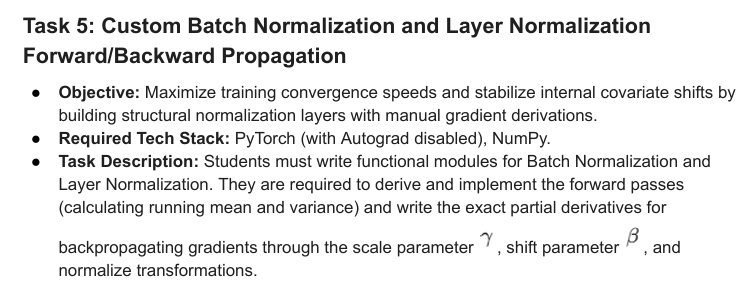

In [1]:
!pip install torch numpy matplotlib

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt

In [3]:
Batch = 100
Features = 10

In [4]:
torch.manual_seed(42)

X = torch.randn(100, 10)

print("Input shape:", X.shape)

Input shape: torch.Size([100, 10])


In [5]:
features = 10

gamma = torch.ones(features)

beta = torch.zeros(features)

running_mean = torch.zeros(features)

running_var = torch.ones(features)

In [6]:
def batch_norm_forward(
    X,
    gamma,
    beta,
    running_mean,
    running_var,
    momentum=0.1,
    eps=1e-5
):

    mean = X.mean(dim=0)

    variance = X.var(
        dim=0,
        unbiased=False
    )

    X_normalized = (
        (X - mean)
        /
        torch.sqrt(variance + eps)
    )

    output = (
        gamma * X_normalized
        + beta
    )

    # Running statistics
    running_mean[:] = (
        momentum * mean
        +
        (1 - momentum) * running_mean
    )

    running_var[:] = (
        momentum * variance
        +
        (1 - momentum) * running_var
    )

    return output, X_normalized, mean, variance

In [7]:
bn_output, bn_normalized, bn_mean, bn_variance = batch_norm_forward(
    X,
    gamma,
    beta,
    running_mean,
    running_var
)

print("BatchNorm output shape:")
print(bn_output.shape)

BatchNorm output shape:
torch.Size([100, 10])


In [8]:
print("Mean:")
print(bn_mean)

print("\nVariance:")
print(bn_variance)

Mean:
tensor([-0.1565,  0.1267, -0.0186, -0.0880, -0.1554,  0.0758,  0.0705,  0.0403,
         0.0813,  0.0661])

Variance:
tensor([1.0853, 1.2197, 0.9055, 1.1074, 0.7587, 0.9787, 1.0883, 0.7969, 0.8627,
        1.1601])


In [9]:
print(
    "\nOutput mean:",
    bn_output.mean(dim=0)
)

print(
    "\nOutput variance:",
    bn_output.var(
        dim=0,
        unbiased=False
    )
)


Output mean: tensor([ 9.5367e-09,  9.5367e-09,  0.0000e+00, -9.5367e-09,  9.5367e-09,
         2.3842e-08, -5.9605e-09,  7.1526e-09, -4.7684e-09, -4.7684e-09])

Output variance: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000])


In [10]:
def batch_norm_backward(
    dout,
    X_normalized,
    variance,
    gamma,
    eps=1e-5
):

    N = dout.shape[0]

    dgamma = torch.sum(
        dout * X_normalized,
        dim=0
    )

    dbeta = torch.sum(
        dout,
        dim=0
    )

    dx = (
        gamma
        /
        torch.sqrt(variance + eps)
    ) * (
        dout
        - dout.mean(dim=0)
        - X_normalized *
        torch.mean(
            dout * X_normalized,
            dim=0
        )
    )

    return dx, dgamma, dbeta

In [11]:
dout = torch.ones_like(
    bn_output
)

dx, dgamma, dbeta = batch_norm_backward(
    dout,
    bn_normalized,
    bn_variance,
    gamma
)

print("dx shape:", dx.shape)

print("dgamma shape:", dgamma.shape)

print("dbeta shape:", dbeta.shape)

dx shape: torch.Size([100, 10])
dgamma shape: torch.Size([10])
dbeta shape: torch.Size([10])


In [12]:
features = 10

gamma_ln = torch.ones(features)

beta_ln = torch.zeros(features)

In [13]:
def layer_norm_forward(
    X,
    gamma,
    beta,
    eps=1e-5
):

    mean = X.mean(
        dim=1,
        keepdim=True
    )

    variance = X.var(
        dim=1,
        keepdim=True,
        unbiased=False
    )

    X_normalized = (
        (X - mean)
        /
        torch.sqrt(
            variance + eps
        )
    )

    output = (
        gamma * X_normalized
        + beta
    )

    return (
        output,
        X_normalized,
        mean,
        variance
    )

In [14]:
ln_output, ln_normalized, ln_mean, ln_variance = layer_norm_forward(
    X,
    gamma_ln,
    beta_ln
)

print(
    "LayerNorm output:",
    ln_output.shape
)

LayerNorm output: torch.Size([100, 10])


In [15]:
print(
    "First sample mean:",
    ln_mean[0]
)

print(
    "First sample variance:",
    ln_variance[0]
)

First sample mean: tensor([0.0902])
First sample variance: tensor([1.8933])


In [16]:
def layer_norm_backward(
    dout,
    X_normalized,
    variance,
    gamma,
    eps=1e-5
):

    features = dout.shape[1]

    dgamma = torch.sum(
        dout * X_normalized,
        dim=0
    )

    dbeta = torch.sum(
        dout,
        dim=0
    )

    dx = (
        gamma
        /
        torch.sqrt(
            variance + eps
        )
    ) * (
        dout
        - dout.mean(
            dim=1,
            keepdim=True
        )
        - X_normalized *
        torch.mean(
            dout * X_normalized,
            dim=1,
            keepdim=True
        )
    )

    return dx, dgamma, dbeta

In [17]:
dout = torch.ones_like(
    ln_output
)

dx_ln, dgamma_ln, dbeta_ln = layer_norm_backward(
    dout,
    ln_normalized,
    ln_variance,
    gamma_ln
)

print("dx:", dx_ln.shape)

print("dgamma:", dgamma_ln.shape)

print("dbeta:", dbeta_ln.shape)

dx: torch.Size([100, 10])
dgamma: torch.Size([10])
dbeta: torch.Size([10])


In [18]:
print(
    "BatchNorm mean:",
    bn_output.mean().item()
)

print(
    "BatchNorm variance:",
    bn_output.var().item()
)

print()

print(
    "LayerNorm mean:",
    ln_output.mean().item()
)

print(
    "LayerNorm variance:",
    ln_output.var().item()
)

BatchNorm mean: -1.907348723406699e-09
BatchNorm variance: 1.0009907484054565

LayerNorm mean: -5.7220459481754915e-09
LayerNorm variance: 1.0009868144989014


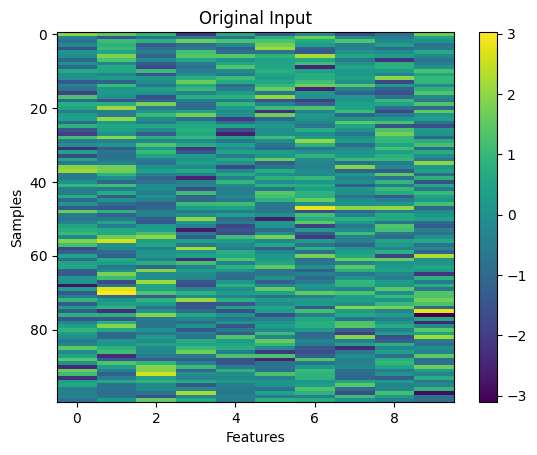

In [19]:
plt.imshow(
    X.numpy(),
    aspect="auto"
)

plt.title(
    "Original Input"
)

plt.xlabel("Features")
plt.ylabel("Samples")

plt.colorbar()

plt.show()

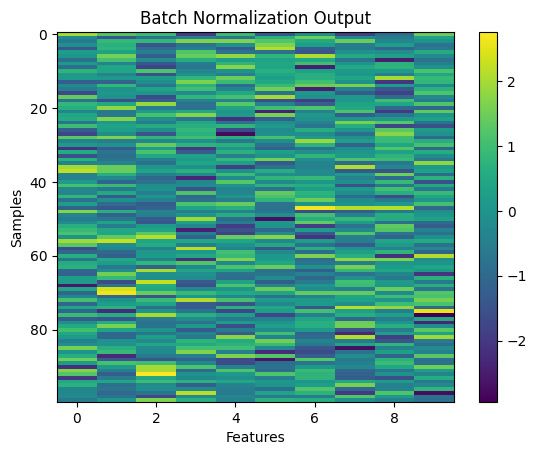

In [20]:
plt.imshow(
    bn_output.detach().numpy(),
    aspect="auto"
)

plt.title(
    "Batch Normalization Output"
)

plt.xlabel("Features")
plt.ylabel("Samples")

plt.colorbar()

plt.show()

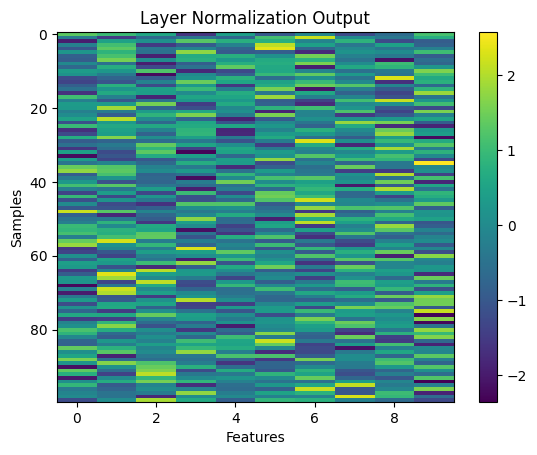

In [21]:
plt.imshow(
    ln_output.detach().numpy(),
    aspect="auto"
)

plt.title(
    "Layer Normalization Output"
)

plt.xlabel("Features")
plt.ylabel("Samples")

plt.colorbar()

plt.show()